In [ ]:
#Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.ticker as ticker
import seaborn as sns
import json
import os

In [ ]:
#Função para abrir arquivos .json com os resultados e retornar lista com dataframes

def prepare_dict_results(results_path, export=False):
    files = ['results_dist_10_2.json', 'results_dist_10_pca_2.json', 'results_dist_1_2.json',
             'results_dist_1_pca_2.json', 'results_dist_20_2.json','results_dist_20_pca_2.json'] #arquivos com os resultados
    tags = ['10_khz', 'pca_10_khz', '1_khz', 'pca_1_khz', '20_khz', 'pca_20_khz'] #Lista com os nomes dos experimentos
    models = ['Gauss', 'KNN', 'RF', 'SVM', 'XGBoost', 'NN'] #Lista com os modelos de aprendizado de máquina
    n_rows = [1200000, 1200000, 120000, 120000, 2400000, 2400000] #Lista com o número de amostras dos experimentos
    results = {} #Dicionário vazio
    for i in range(len(files)):
        file_path = os.path.join(results_path, files[i]) #Cria o caminho do arquivo
        with open(file_path, 'r') as file:
            data = json.load(file) #Abre o arquivo .json

        dfs_l = {} #Dicionário vazio

        for j in range(len(models)):
            df = pd.DataFrame(data[models[j]]) #Cria dataframe com os dados do arquivo .json
            df['model'] = models[j] #Cria o coluna dos modelos
            df['model'] = df['model'].replace({'Gauss': 'GNB'}) #Altera o nome do modelo Gauss para GNB
            df['n_samples'] = n_rows[i] #Adiciona coluna de número de amostras
            df['experiment'] = tags[i] #Adiciona coluna do nome dos experimentos
            df = df.convert_dtypes() #Converte automáticamente os tipos de dados
            dfs_l[models[j]] = df #Adiciona o dataframe no dicionário

        df_join = pd.concat(dfs_l) #Junta os datafrmaes do dicionário

        if export==True:
            df_join.to_csv(f'{results_path}/result_dist_{tags[i]}.csv', sep=';', decimal=',', index=False) #Exporta o dataframe criado em arquivo .csv caso 
                                                                                                           #a variável export seja igual a True

        results[tags[i]] = df_join #Adiciona o dataframe no dicionário

    return results #Retorna dicionário com dataframes dos resultados

In [ ]:
results = prepare_dict_results('Resultados_dist_2', export=True) #Chama a função e armazena o dicionário com os dataframes, exportando em arquivo .csv

In [ ]:
df_join = pd.concat(results) #Junta os dataframes do dicionário em um só

In [ ]:
order_titles = ['20 kHz', '10 kHz', '1 kHz', '20 kHz + PCA', '10 kHz + PCA', '1 kHz + PCA'] #Cria lista com os títulos dos gráficos

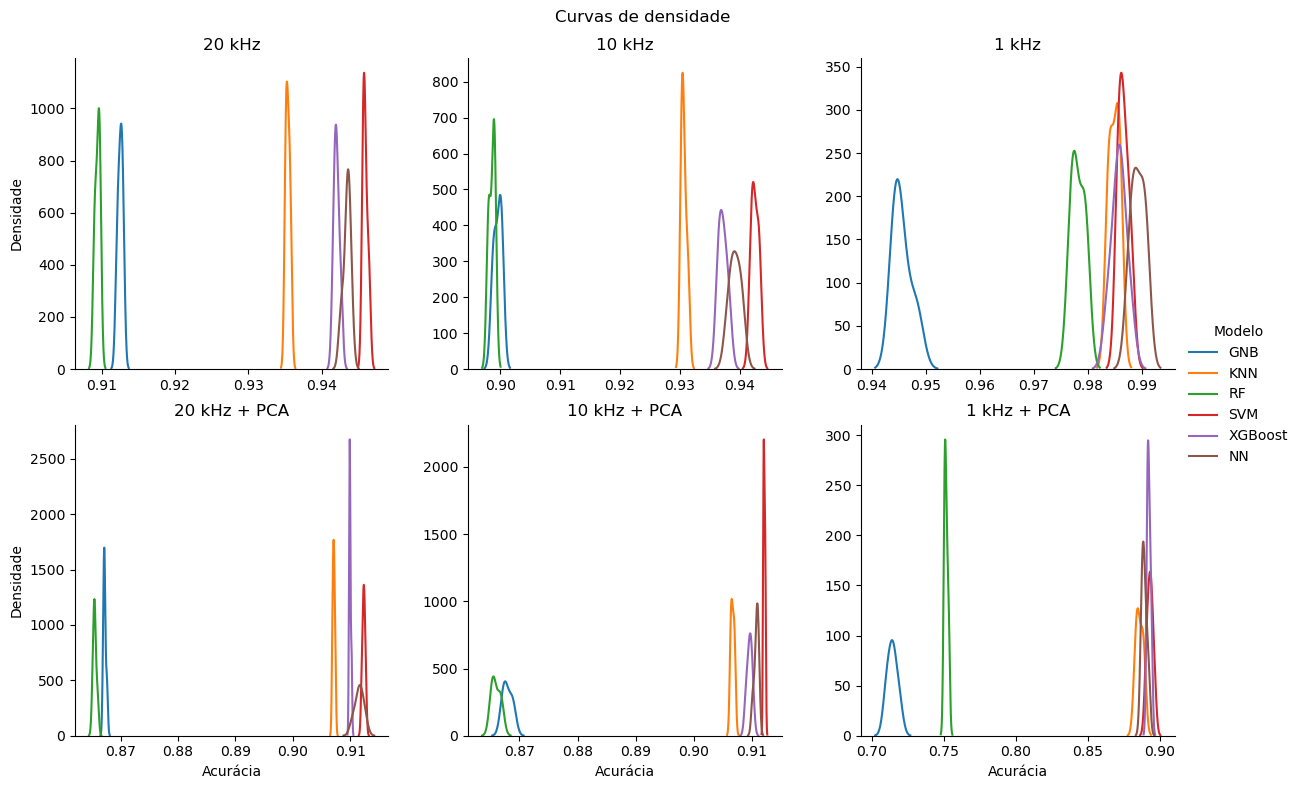

In [ ]:
ordered_exp = ['20_khz', '10_khz', '1_khz', 'pca_20_khz', 'pca_10_khz', 'pca_1_khz'] #Ordem de plotagem dos gráficos

g = sns.FacetGrid(df_join, col='experiment', hue='model', col_wrap=3, 
                  col_order=ordered_exp, height=4, sharey=False, sharex=False) #Cria FacetGrid com o dataframe, filtrando pela coluna experiment e pela coluna model,
                                                                               #ordenando os gráficos de acordo com a lista ordered_exp, não compartilhando os eixos x e y
g.map(sns.kdeplot, 'test_score') #Cria gáfico de densidade com a coluna test_score
g.add_legend() #Adiciona a legenda
g.legend.set_title('Modelo') #Altera o título da legenda para Modelo
g.fig.suptitle('Curvas de densidade') #Cria título da imagem com os gráficos
g.fig.subplots_adjust(top=0.92) #Ajusta a posição do título
for idx, ax in enumerate(g.axes.flat):
    ax.set_title(order_titles[idx]) #Altera o título dos gráficos

g.set_xlabels('Acurácia') #Define o título do eixo x para Acurácia
g.set_ylabels('Densidade') #Define o título do eixo y para Densidade

plt.savefig('Resultados_dist_2/Grid_plot_dist.png') #Salva a figura em arquivo .png
plt.show() #Mostra a figura